# COGS 108 - EDA Checkpoint

## Authors

- Noor Bouzelfane: Experimental investigation, Visualization, Writing – original draft
- Rylee Correa:  Experimental investigation, Visualization, Writing – original draft
- Sarena Pham:  Experimental investigation, Visualization, Writing – original draft
- Rachel Handran:  Experimental investigation, Visualization, Writing – original draft
- Daniel Mulford:  Experimental investigation, Visualization, Writing – original draft

# Research Question

Among college students, how does clothing purchasing type, frequency, and average price spent relate to disposal reason and method?





## Background and Prior Work

Fast fashion is a clothing production model where clothing is produced quickly and cheaply, with rapid turnover due to changing trends and high-volume manufacturing. This way of production has completely changed the fashion industry, how we see trends, and how we consume clothes, especially in the past two decades.

On one hand, this model has been praised for making clothing more affordable to people who may not have been able to afford expensive, high quality clothing. However, it also raises concerns surrounding textile lifespan. Garments are increasingly made in ways that shorten the usable life, and this contributes to waste, pollution, and higher resource demand.
Prior research shows that fast fashion production practices directly reduce textile lifespan. According to the Sustainability Directory, fast fashion brands more often use inexpensive, synthetic fibers in their clothing. These fabrics degrade quickly with regular wear and washing, leading the clothes to lose structural integrity after fewer uses.<a name="#ref1"></a>[<sup>1</sup>](#note1) Additionally, the constant release of new clothing styles encourages consumers to discard more clothing that is not necessarily unusable, but outdated. According to the United States Environmental Protection Agency, the total mass of textile waste generated each year has increased roughly tenfold since 1960 while the total United States population has barely doubled.<a name="#ref4"></a>[<sup>4</sup>](#note4) The Geneva Environment Network also reported that approximately 85% of textiles are discarded each year, mostly ending up in landfills or incinerators rather than being recycled.<a name="#ref2"></a>[<sup>2</sup>](#note2) They found that the fashion industry operates a model where clothing is produced at high volume with low costs, but is rarely kept in circulation for very long.

The environmental effects of fast fashion are commonly discussed, but specific and reliable information regarding numbers is often inconsistent or difficult to prove. A Vox investigation “Fashion has a misinformation problem. That’s bad for the environment.” by Alden Wicker shows that, while there is clear evidence of pollution and overproduction, data on textile waste and garment lifespan are mainly sourced from limited regional studies.<a name="#ref3"></a>[<sup>3</sup>](#note3) They noted that claims about how quickly clothing is thrown out and how much ends up in landfills varies widely across sources. This makes it difficult to regulate the industry at all or evaluate sustainability claims from most companies.

The lack of definite consumer-level data surrounding the garment industry led us to want to examine the clothing use and disposal practices of specific populations, in our case college students. Rather than exclusively using estimated data that can be inconsistent, we will analyze self-reported behaviors from a smaller population. Our sources have provided us with a background for examining how college students consume and ultimately dispose of clothing.

1. <a name="note1"></a> [^](#ref1) Sustainability Directory, “How Does Fast Fashion Influence Textile Lifespan?”  
https://fashion.sustainability-directory.com/question/how-does-fast-fashion-influence-textile-lifespan/
1. <a name="note2"></a> [^](#ref2) Geneva Environment Network, “Sustainable Fashion”  
https://www.genevaenvironmentnetwork.org/resources/updates/sustainable-fashion/
1. <a name="note3"></a> [^](#ref3) Wicker, A. (2020). “Fashion Has a Misinformation Problem. That’s Bad for the Environment.” Vox.  
https://www.vox.com/the-goods/2020/1/27/21080107/fashion-environment-facts-statistics-impact
1. <a name="note4"></a> [^](#ref4) United States Environmental Protection Agency. 2025. "Textiles: Material-Specific Data". https://www.epa.gov/facts-and-figures-about-materials-waste-and-recycling/textiles-material-specific-data


## Hypothesis


We predict that among college students, higher clothing purchase frequency will correlate with a higher likelihood to throw away unwanted clothing. Additionally, we predict that students who buy secondhand clothing will be more likely to donate unwanted clothing, while less likely to dispose of it due to damage. This is based on the Sustainability Directory report that stated fast fashion brands use materials that are less resistant to normal wear and tear, and tend to have shorter release and production cycles, leading to increased consumption and disposal.


## Data

### Data overview

- Dataset Name: Clothing Purchasing Behavior Survey 
  - Link to the dataset: https://docs.google.com/spreadsheets/d/1CUZMOx38vzylttOMPj1qxSOQkBAn_Ggj1KFLPMtAwSU/edit?usp=sharing
  - Number of observations: 130
  - Number of variables: Six
  - Description of the variables most relevant to this project: Clothing Purchase Type (New vs. Secondhand), Purchase Frequency, Average Price, Disposal Method, Disposal Reason, Area of Study
  - Descriptions of any shortcomings this dataset has with respect to the project Student fields of studies may not be representative of college students at large


In [31]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
# Setup code -- this only needs to be run once after cloning the repo!
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://drive.google.com/uc?export=download&id=19EqrJii4e7Vf7i6PjqPKvJCurtEL-2fW', 'filename':'Clothing Purchasing Behavior.csv'},
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress: 100%|██████████| 1/1 [00:01<00:00,  1.40s/it]

Successfully downloaded: Clothing Purchasing Behavior.csv


### Clothing Purchasing Behavior Survey

 Clothing Purchase Type is what we hypothesize is the predictor in our data, and it is a categorical variable. It describes the average condition of the clothing respondents bought in the past year, as they report it. It is an ordinal variable with five mutually exclusive levels: “Almost always new”, “Mostly new, some secondhand”, “About equal new and secondhand”,  “Mostly secondhand, some new”, and “Almost always secondhand”. 
	
The four variables we hypothesize to be predicted by clothing purchase type are Purchase Frequency, Average Price, Disposal Method, and Disposal Reason. Purchase Frequency is a categorical variable that describes what respondents think is their average frequency of clothing purchases in the past year. It is an ordinal variable with five mutually exclusive levels: “About once per week or more”, “About once per month”, “Every few months”, “About once a year”, and “Every few years”. Average Price is a numerical variable that describes the range in dollars that respondents think they typically spend on a single shirt/top. It is an ordinal variable with five mutually exclusive levels: “0-5”, “5-15”, “15-35”, “35-75”, and “75+”. Disposal Method is a categorical variable that describes the method by which respondents typically dispose of their clothes, according to them. It is a nominal variable with five mutually exclusive categories: “Donate”, “Sell”, “Throw away”, “Textile recycling program”, and “Other (fill in)”. Disposal Reason is a categorical variable that describes what respondents think are their primary reasons for disposing of their clothes. It is a nominal variable with six categories, with up to two optionally co-occurring; the categories are “Torn/Broken”, “Doesn’t fit anymore”, “Don’t like it anymore”, “Selling for money”, “Freeing up space”, “Other (fill in)”. 

Area of Study is a variable that we anticipate affecting outcomes, despite not hypothesizing it as the predictor of outcomes. It is a categorical variable that describes the primary field of study of college students responding to our survey. It is a nominal variable with seven mutually exclusive categories: “Arts & Humanities”, “Biological Sciences”, “Engineering”, “Health Sciences”, “Social Sciences”, “Physical Sciences”, and “Other (fill in)”. One concern with our survey dataset is the disproportionate amount of engineering student respondents, since most college students are not necessarily engineering majors. Our sample is somewhat biased towards the characteristics of our team because of how we are sourcing survey responses; for example, we got many responses from the ECE 101 Piazza page. An additional concern with the dataset is that the Disposal Method variable may be unrepresentative of our population due to social desirability bias; although our survey is anonymous and we aimed to use neutral language, respondents may actually throw away clothes more often than they report. 


### Tidying

In [33]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
import pandas as pd

df = pd.read_csv('data/00-raw/Clothing Purchasing Behavior.csv')

column_names = ['timestamp', 'consent', 'major', 'new_vs_secondhand', 'purchase_freq', 'avg_price', 'disposal_method', 'disposal_reason']
df.columns = column_names

# Number of rows
df.shape[0]
# Multiple variables are embedded in the `disposal_reason` column, separated by commas.
# What are the unique reasons for disposal?

unique_reasons = set[str]()
for response in df['disposal_reason']:
    unique_reasons.update(response.split(', '))

def count_occurrences(reason: str) -> int:
    return df['disposal_reason'].str.contains(reason).sum()

disposal_reason_df = pd.DataFrame(unique_reasons, columns=['disposal_reason'])
disposal_reason_df['count'] = disposal_reason_df['disposal_reason'].apply(count_occurrences)
disposal_reason_df.sort_values(by='count', ascending=False)
# Give common disposal reasons their own columns; collect singletons in a column called 'other'

df_tidy = df.copy()

disposal_col_names = {
    "Doesn't fit anymore": "disposal_reason_doesnt_fit",
    "Don't like it anymore": "disposal_reason_dont_like",
    "Freeing up space": "disposal_reason_space",
    "Torn/Broken": "disposal_reason_torn",
    "Selling for money": "disposal_reason_money"
}

for reason, new_col in disposal_col_names.items():
    df_tidy[new_col] = df_tidy['disposal_reason'].str.contains(reason).astype(bool)

def is_other(response: str) -> bool:
    reasons = response.split(', ')
    other = False
    for reason in reasons:
        if reason not in [*disposal_col_names.keys()]:
            other = True
    return other

df_tidy['disposal_reason_other'] = df_tidy['disposal_reason'].apply(is_other)
df_tidy = df_tidy.drop(columns=['disposal_reason'])

# Now that each variable has its own column, the dataset is tidy.
df_tidy.to_csv('data/01-interim/survey_tidy.csv', index=False)
df_tidy.head()

,timestamp,consent,major,new_vs_secondhand,purchase_freq,avg_price,disposal_method,disposal_reason_doesnt_fit,disposal_reason_dont_like,disposal_reason_space,disposal_reason_torn,disposal_reason_money,disposal_reason_other
0,2/5/2026 15:18:59,Yes,NaN,About equal new and secondhand,About once per month,5-15,"Donate (Thrift store, handing down)",True,False,False,False,True,False
1,2/5/2026 15:20:07,Yes,NaN,"Mostly new, some secondhand",About once per month,15-35,I actually have never thrown a piece of clothing away in my life !!!!!,False,False,False,False,False,True
2,2/5/2026 15:21:04,Yes,NaN,"Mostly new, some secondhand",About once a year,5-15,"Donate (Thrift store, handing down)",False,True,False,True,False,False
3,2/5/2026 15:25:50,Yes,NaN,"Mostly secondhand, some new",About once per month,15-35,I dnot get rid of clothes,False,True,False,False,False,True
4,2/5/2026 17:04:04,Yes,NaN,"Mostly new, some secondhand",Every few months,5-15,"Donate (Thrift store, handing down)",True,True,False,False,False,False


### Cleaning

In [34]:
# Where do we have missing values?
df_tidy.loc[df_tidy.isna().any(axis=1)]

,timestamp,consent,major,new_vs_secondhand,purchase_freq,avg_price,disposal_method,disposal_reason_doesnt_fit,disposal_reason_dont_like,disposal_reason_space,disposal_reason_torn,disposal_reason_money,disposal_reason_other
0,2/5/2026 15:18:59,Yes,NaN,About equal new and secondhand,About once per month,5-15,"Donate (Thrift store, handing down)",True,False,False,False,True,False
1,2/5/2026 15:20:07,Yes,NaN,"Mostly new, some secondhand",About once per month,15-35,I actually have never thrown a piece of clothing away in my life !!!!!,False,False,False,False,False,True
2,2/5/2026 15:21:04,Yes,NaN,"Mostly new, some secondhand",About once a year,5-15,"Donate (Thrift store, handing down)",False,True,False,True,False,False
3,2/5/2026 15:25:50,Yes,NaN,"Mostly secondhand, some new",About once per month,15-35,I dnot get rid of clothes,False,True,False,False,False,True
4,2/5/2026 17:04:04,Yes,NaN,"Mostly new, some secondhand",Every few months,5-15,"Donate (Thrift store, handing down)",True,True,False,False,False,False
5,2/5/2026 19:34:45,Yes,NaN,Almost always new,About once a year,5-15,"Donate (Thrift store, handing down)",True,True,False,False,False,False
6,2/5/2026 19:36:05,Yes,NaN,Almost always new,Every few months,15-35,"Donate (Thrift store, handing down)",False,True,True,False,False,False
7,2/6/2026 16:41:22,Yes,NaN,Almost always new,Every few months,35-75,Throw away (Trash/Landfill),True,True,False,False,False,False
8,2/6/2026 17:39:52,Yes,NaN,Almost always secondhand,About once per week or more,15-35,use as kitchen rag,False,False,False,True,False,False
9,2/6/2026 22:15:14,Yes,NaN,Almost always new,Every few years,15-35,"Donate (Thrift store, handing down)",False,True,False,True,False,False


In [35]:
# Major is the only column with missing values. Since we can make valid inferences without it, we will simply fill them in.
df_clean = df_tidy.copy()
df_clean['major'] = df_clean['major'].fillna('Unknown')

In [36]:
# Let's examine the free responses in order to see if there are any problematic entries.

pd.set_option('display.max_colwidth', None)

disposal_method_presets = [
    "Donate (Thrift store, handing down)",
    "Sell (eBay, yard sale)",
    "Throw away (Trash/Landfill)",
    "Textile recycling program"
]

df['disposal_method'].loc[~df['disposal_method'].isin(disposal_method_presets)]

1                                        I actually have never thrown a piece of clothing away in my life !!!!!
3                                                                                     I dnot get rid of clothes
8                                                                                            use as kitchen rag
56                                                                                       Keep them in my closet
59                                                                      Used for cleaning and soaking up spills
60                                                                                                      Keep it
65     Donate/hand down, but I very rarely get rid of clothes and my wardrobe has not changed much for 4 years.
95                                                         I cut it up into scrap fabric for my sewing projects
125                       I cut it up and use it as patches/other sewing projects, not sure what this co

In [37]:
df['disposal_reason'].loc[df_clean['disposal_reason_other']]

1                                                                                                                    I do not throw anything away ever
3      Don't like it anymore, It didn't let me choose multiple, but I do all the above. But primarily because I don't like it or i need to make space.
56                                                                                                                                             I don't
59                                                                                                                        Torn/Broken, heavily stained
122                                                                                                                    Don't like it anymore, Stained 
Name: disposal_reason, dtype: object

In [38]:
# Respondent 3 had trouble selecting the survey options, so their response is invalid. Otherwise, everything looks OK.
df_clean = df_clean.drop(index=3)

In [39]:
# Finally, drop nonconsenting participants.
df_clean = df_clean[df_clean['consent'] == "Yes"]
df_clean = df_clean.drop(columns=['consent'])

df_clean.to_csv('data/02-processed/survey_clean.csv', index=False)

df_clean.head()

,timestamp,major,new_vs_secondhand,purchase_freq,avg_price,disposal_method,disposal_reason_doesnt_fit,disposal_reason_dont_like,disposal_reason_space,disposal_reason_torn,disposal_reason_money,disposal_reason_other
0,2/5/2026 15:18:59,Unknown,About equal new and secondhand,About once per month,5-15,"Donate (Thrift store, handing down)",True,False,False,False,True,False
1,2/5/2026 15:20:07,Unknown,"Mostly new, some secondhand",About once per month,15-35,I actually have never thrown a piece of clothing away in my life !!!!!,False,False,False,False,False,True
2,2/5/2026 15:21:04,Unknown,"Mostly new, some secondhand",About once a year,5-15,"Donate (Thrift store, handing down)",False,True,False,True,False,False
4,2/5/2026 17:04:04,Unknown,"Mostly new, some secondhand",Every few months,5-15,"Donate (Thrift store, handing down)",True,True,False,False,False,False
5,2/5/2026 19:34:45,Unknown,Almost always new,About once a year,5-15,"Donate (Thrift store, handing down)",True,True,False,False,False,False


## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



In [40]:
import pandas as pd

df = pd.read_csv('data/02-processed/survey_clean.csv')

#### Shopper Type vs. Average Price


Text(0.5, 0, 'Shopper Type')

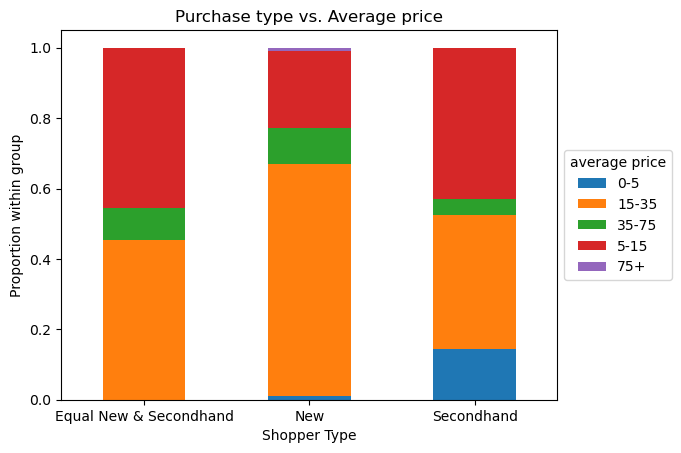

In [41]:
# mapping the new vs secondhand responses to have shorter labels
#Purchase type vs. Average price
new_vs_secondhand_map = {
   'Almost always new': 'New',
   'Mostly new, some secondhand': 'New',
   'About equal new and secondhand': 'Equal New & Secondhand',
   'Mostly secondhand, some new': 'Secondhand',
   'Almost always secondhand': 'Secondhand'
}

df['new_vs_secondhand'] = df['new_vs_secondhand'].map(new_vs_secondhand_map)

# Group by purchase type and disposal method, count the number of responses, and reshape for plotting
plot_df = df.groupby(['new_vs_secondhand', 'avg_price']).size().unstack('avg_price').fillna(0)

# Normalize by shopper type to get proportion of shopper groups that use each disposal method
sub_df = plot_df.div(plot_df.sum(axis=1), axis=0)

# Generate plot
ax = sub_df.plot(kind='bar', stacked=True, rot=0,
                 title='Purchase type vs. Average price')

# Customize plot labels
ax.legend(title='average price', loc='center left', bbox_to_anchor=(1.0, 0.5))
ax.set_ylabel("Proportion within group")
ax.set_xlabel("Shopper Type")

#### Section 2 of EDA if you need it  - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [42]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

## Ethics


### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

> We will place a summary of our research goals at the top of the form: "We are a student team from the UCSD COGS 108 course, conducting research on clothing consumption and disposal habits of college students. Your survey responses will be aggregated in any results we publish." Checkbox: I consent to participating in this research.

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

> It is important to mitigate bias since this is self-reporting of consumer habits. We have phrased the survey questions carefully to be objective and simple to answer. It is possible that students will be reminded of fast fashion as a whole and try to self-report on more sustainable habits than is actually true.

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

 > We will not collect any PII. We will aggregate all results published or shared.

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

> This will be difficult to test, but we acknowledge that college students in COGS 108 may not be a representative sample of the general college student population of the world. We are in the U.S., southern California, which is not representative of colleges in other areas.

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?

 > We will use Google forms to collect the survey data, which has built in encryption and security. We will not ask for their email or any PII.

 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?

> No, the data will be completely anonymous so we will not be able to delete data since it is not linked to a person's email.

 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

> No, the data is not PII or sensitive.

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?
 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

 > Possible sources of bias for our survey data include selection and response biases. Giving our survey to fellow COGS 108 students via Ed is a convenient sample, but it is not necessarily representative of all UCSD students. For example, since COGS 108 students are mostly social science or natural science majors, perhaps major is a confounding variable in students’ clothing lifespans. Furthermore, perhaps arts majors are more likely to thrift than STEM majors. To control for these factors, we can post our survey to the r/UCSD Reddit and possibly to other colleges’ Reddits to get a broader sample of college students. Additionally, survey responses may be subject to social desirability bias. It is less socially desirable to say you usually throw your unwanted clothes in the trash than to say you donate them. To mitigate social desirability bias, we can choose more neutral language in our phrasing of questions and responses, and assure participants that their responses are anonymous. For example, instead of using the words “landfill” or “trash,” which have more negative connotations, we can use the more neutral terms “throw away” or “recycle.” 

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

 > 	We will choose the appropriate plots to visualize the data and prioritize clarity and accuracy over representations that may seem to prove our hypothesis at first glance. 

 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?

> For our survey, we will not collect email addresses or names in our Google Form. 

 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

> Through GitHub commits with informative messages and detailed descriptions of the analysis process, we will ensure we can re-trace our steps in order to proofread our work and troubleshoot. 

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 - [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?

 > 	If anyone is harmed by the implications of our analysis, we will communicate with those people first and listen to their feedback. Then we will make the appropriate changes to our analysis, compensate those harmed, and counteract the effects of our mistakes by proactively facing issues of bias and harm instead of waiting for them to happen. 

 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

> We can protect access to our analysis for only people who are going to use it for specific, noncommercial purposes. We can do this by keeping our work private and requiring an email request to see the data. This would be necessary to prevent unintended use, such as a fashion brand utilizing our statistics for ‘greenwashing’ purposes; this data analysis is for educational purposes and for promoting civic/environmental good, not marketing. 

## Team Expectations 

* Primarily in person meeting, zoom is 2nd option
* Be active on discord
* Be respectful and responsible


## Project Timeline Proposal

| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 1/20  |  11:00 AM | Communicate on Discord; brainstorm topics  | Communication, expectations; Group Survey Form; Background research| 
| 1/26  |  11:30 AM |  Brainstorm research questions | Previous Project Review; Plan for Project Proposal due 2/4 | 
| 2/5  | 2:30 PM | Submit project proposal; Professor Office Hours | Make Google Form for survey; send out to friends  |
| 2/12  | 2:30 PM| Bring back results from pilot survey; Get feedback from TA on proposal | Send out survey to class, reddits, etc; discuss potential bias in survey; Divide labor for Data Checkpoint due 2/18 |
| 2/19  | 2:30 PM| Begin data cleaning code development on initial survey data; Continue distributing survey widely; Complete data checkpoint | Brainstorm analysis methods; Plan for EDA checkpoint due 3/4 |
| 2/26  | 2:30 PM | Have EDA code and visualization ready | Divide labor for EDA checkpoint, review our EDA parts |
| 3/5  | 2:30 PM  | Submit EDA checkpoint | Discuss analysis methods, divide labor for final submission |
| 3/12  | 2:30 PM  | Load final data (cut off survey responses 3/11) | Review final submission, make final adjustments |